<a href="https://colab.research.google.com/github/IT24100378/ToxicCommentNLPfinal/blob/Lowercasing/Lowercasing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# Load dataset
df = pd.read_csv("data/balanced.csv")


# Show dataset info and first 5 rows
print("\nDataset Info:")
print(df.info())
print("\nFirst 5 Rows:")
print(df.head())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   comment_text  16000 non-null  object
 1   toxic         16000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 250.1+ KB
None

First 5 Rows:
                                        comment_text  toxic
0  "\r\n\r\n ""Lighten up, Francis"" \r\n\r\nOn s...      0
1  Lisa Williams is a total fraud \r\nNo offense ...      1
2  I am David in DC, not DavidinDC. On at least o...      1
3  FUCK YOU  \r\n\r\n \r\nFuck You keep blocking ...      1
4  Both entries are on the same subject, they sho...      0



Before Preprocessing Dataset Summary:
         char_count    word_count
count  16000.000000  16000.000000
mean     356.329875     60.688688
std      624.177094    104.967779
min        5.000000      1.000000
25%       76.000000     13.000000
50%      167.000000     29.000000
75%      362.000000     63.000000
max     5000.000000   1403.000000


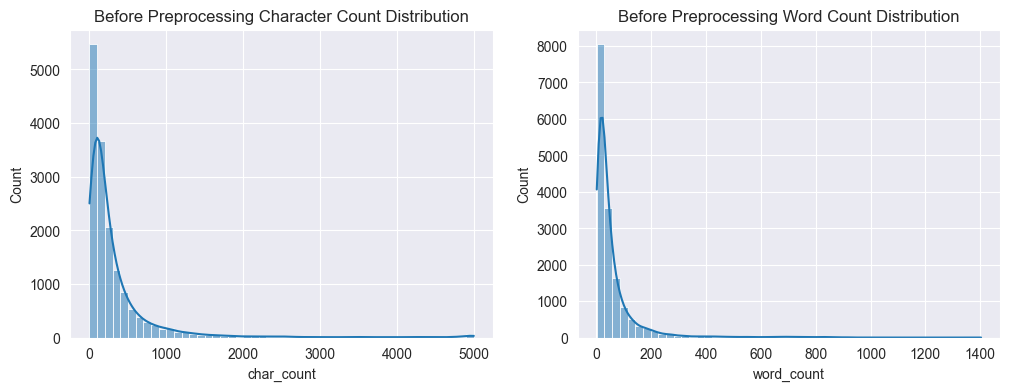

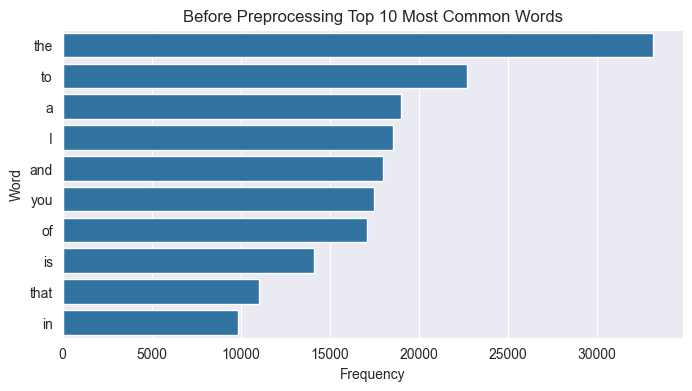

In [2]:
# Function for EDA
def text_eda(data, column_name, title_prefix=""):
    # Add text length features
    data["char_count"] = data[column_name].apply(len)
    data["word_count"] = data[column_name].apply(lambda x: len(str(x).split()))

    # Summary statistics
    print(f"\n{title_prefix} Dataset Summary:")
    print(data[[column_name, "char_count", "word_count"]].describe())

    # Distribution plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(data["char_count"], bins=50, ax=axes[0], kde=True)
    axes[0].set_title(f"{title_prefix} Character Count Distribution")
    sns.histplot(data["word_count"], bins=50, ax=axes[1], kde=True)
    axes[1].set_title(f"{title_prefix} Word Count Distribution")
    plt.show()

    # Most common words
    all_words = " ".join(data[column_name].astype(str)).split()
    common_words = Counter(all_words).most_common(10)
    common_df = pd.DataFrame(common_words, columns=["Word", "Frequency"])

    plt.figure(figsize=(8,4))
    sns.barplot(x="Frequency", y="Word", data=common_df)
    plt.title(f"{title_prefix} Top 10 Most Common Words")
    plt.show()

 # ----- EDA Before Preprocessing -----
text_eda(df.copy(), "comment_text", title_prefix="Before Preprocessing")

In [3]:
# ----- Preprocessing (Lowercasing) -----
df_preprocessed = df.copy()
df_preprocessed["comment_text"] = df_preprocessed["comment_text"].str.lower()
print(" Data has been preprocessed: all text converted to lowercase.")

 Data has been preprocessed: all text converted to lowercase.



After Preprocessing Dataset Summary:
         char_count    word_count
count  16000.000000  16000.000000
mean     356.329938     60.688688
std      624.177060    104.967779
min        5.000000      1.000000
25%       76.000000     13.000000
50%      167.000000     29.000000
75%      362.000000     63.000000
max     5000.000000   1403.000000


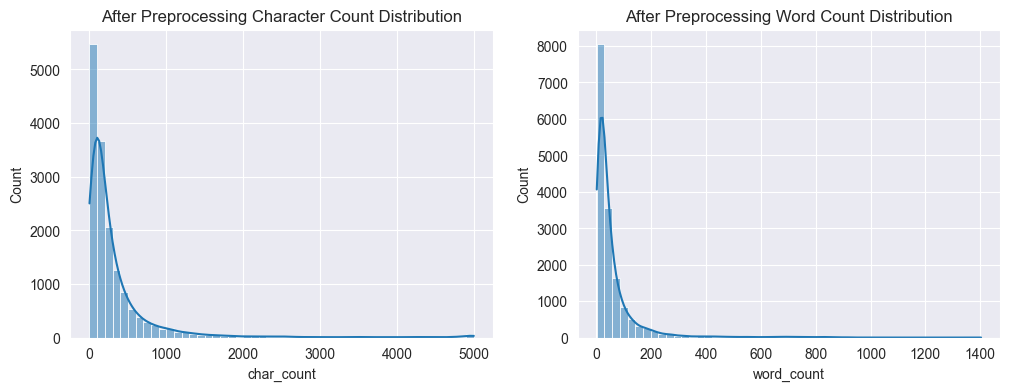

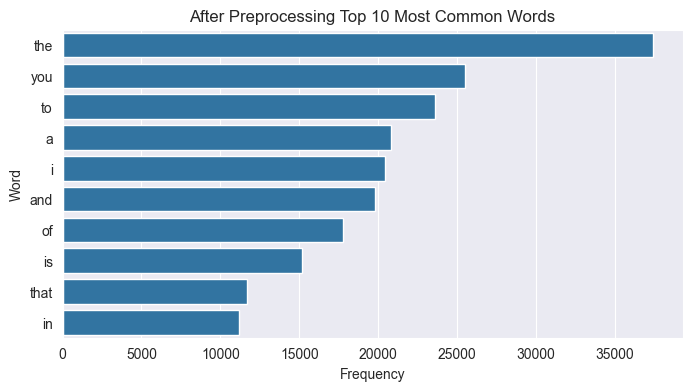

In [4]:
# ----- EDA After Preprocessing -----
text_eda(df_preprocessed.copy(), "comment_text", title_prefix="After Preprocessing")

In [5]:
from collections import Counter

# ----- Compare Top Words Before vs After Preprocessing -----
def compare_top_words(df_original, df_preprocessed, column="comment_text", top_n=10):
    # Top words before
    words_before = " ".join(df_original[column].astype(str)).split()
    common_before = Counter(words_before).most_common(top_n)

    # Top words after
    words_after = " ".join(df_preprocessed[column].astype(str)).split()
    common_after = Counter(words_after).most_common(top_n)

    # Combine into a DataFrame for side-by-side view
    comparison_df = pd.DataFrame({
        "Before Preprocessing": [w for w, _ in common_before],
        "Freq Before": [c for _, c in common_before],
        "After Preprocessing": [w for w, _ in common_after],
        "Freq After": [c for _, c in common_after]
    })

    print("\n Top 10 Most Common Words Before vs After Lowercasing:\n")
    print(comparison_df)

# Run comparison
compare_top_words(df, df_preprocessed)



 Top 10 Most Common Words Before vs After Lowercasing:

  Before Preprocessing  Freq Before After Preprocessing  Freq After
0                  the        33145                 the       37411
1                   to        22701                 you       25502
2                    a        19011                  to       23613
3                    I        18559                   a       20828
4                  and        17980                   i       20406
5                  you        17481                 and       19793
6                   of        17086                  of       17800
7                   is        14108                  is       15190
8                 that        11035                that       11698
9                   in         9824                  in       11176


In [6]:
# ----- Save Preprocessed Dataset -----
df_preprocessed.to_csv("train_preprocessed_lowercased.csv", index=False)

